# Music Subscription Value Analysis

## Overview

This notebook analyzes my Spotify listening history to determine:
- How much I actually use my subscription
- What I'm paying per hour of entertainment
- When and how I listen to music

**Goal:** Quantify the value of my music subscription using real behavioral data.

## Setup

Import necessary libraries and our custom modules.

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add src to path so we can import our modules
import sys
sys.path.append('../src')

# Our custom modules
from load_data import load_streaming_history, validate_data
from process_data import process_streaming_data, aggregate_by_month, get_weekday_weekend_stats
from stats import generate_summary_stats, print_summary
from plots import set_plot_style, plot_monthly_hours, plot_cost_per_hour, plot_hourly_distribution, plot_weekday_weekend_comparison

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
set_plot_style()

print("Setup complete!")

Setup complete!


## Configuration

Set your subscription cost here.

In [2]:
# Update this with your actual subscription cost
SUBSCRIPTION_COST = 10.99  # USD per month

print(f"Analyzing with subscription cost: ${SUBSCRIPTION_COST}/month")

Analyzing with subscription cost: $10.99/month


## Step 1: Load Data

Load the Spotify streaming history JSON files from the `data/` directory.

**What's happening:**
- Reading all `StreamingHistory*.json` files
- Combining them into a single DataFrame
- Validating the expected columns exist

In [3]:
# Load the data
df_raw = load_streaming_history('../data')

# Validate it has the expected format
validate_data(df_raw)

# Preview the raw data
print("\nRaw data preview:")
df_raw.head(10)

Found 1 streaming history file(s)
Loading StreamingHistory0.json...

Loaded 30 streaming records
Date range: 2024-01-15 08:23:00 to 2024-05-05 09:45:00
✓ Data validation passed

Raw data preview:


,endTime,artistName,trackName,msPlayed
0,2024-01-15 08:23:00,Taylor Swift,Anti-Hero,183290
1,2024-01-15 08:27:00,The Weeknd,Blinding Lights,201000
2,2024-01-15 14:32:00,Doja Cat,Paint The Town Red,225000
3,2024-01-16 09:15:00,Olivia Rodrigo,vampire,219000
4,2024-01-16 18:45:00,Bad Bunny,Monaco,242000
5,2024-01-20 11:22:00,SZA,Kill Bill,154000
6,2024-01-20 11:25:00,SZA,Snooze,201000
7,2024-01-21 07:30:00,Metro Boomin,Superhero,183000
8,2024-02-03 16:20:00,Taylor Swift,Cruel Summer,178000
9,2024-02-03 16:23:00,Taylor Swift,Lover,221000


## Step 2: Process Data

Clean and transform the raw data:
- Convert timestamps to datetime objects
- Calculate listening duration in hours/minutes
- Filter out very short plays (< 30 seconds)
- Extract temporal features (month, day of week, hour, etc.)

**Why filter short plays?**
Plays under 30 seconds are likely skips, not actual listening.

In [4]:
# Process the data
df = process_streaming_data(df_raw, min_seconds=30)

# Preview processed data
print("\nProcessed data preview:")
df.head(10)

Processed 30 listening records
Filtered out 0 short plays (< 30s)
Total listening time: 1.7 hours

Processed data preview:


,endTime,artistName,trackName,msPlayed,minutes_played,hours_played,date,year,month,day_of_week,hour_of_day,is_weekend
0,2024-01-15 08:23:00,Taylor Swift,Anti-Hero,183290,3.054833,0.050914,2024-01-15,2024,2024-01,Monday,8,False
1,2024-01-15 08:27:00,The Weeknd,Blinding Lights,201000,3.350000,0.055833,2024-01-15,2024,2024-01,Monday,8,False
2,2024-01-15 14:32:00,Doja Cat,Paint The Town Red,225000,3.750000,0.062500,2024-01-15,2024,2024-01,Monday,14,False
3,2024-01-16 09:15:00,Olivia Rodrigo,vampire,219000,3.650000,0.060833,2024-01-16,2024,2024-01,Tuesday,9,False
4,2024-01-16 18:45:00,Bad Bunny,Monaco,242000,4.033333,0.067222,2024-01-16,2024,2024-01,Tuesday,18,False
5,2024-01-20 11:22:00,SZA,Kill Bill,154000,2.566667,0.042778,2024-01-20,2024,2024-01,Saturday,11,True
6,2024-01-20 11:25:00,SZA,Snooze,201000,3.350000,0.055833,2024-01-20,2024,2024-01,Saturday,11,True
7,2024-01-21 07:30:00,Metro Boomin,Superhero,183000,3.050000,0.050833,2024-01-21,2024,2024-01,Sunday,7,True
8,2024-02-03 16:20:00,Taylor Swift,Cruel Summer,178000,2.966667,0.049444,2024-02-03,2024,2024-02,Saturday,16,True
9,2024-02-03 16:23:00,Taylor Swift,Lover,221000,3.683333,0.061389,2024-02-03,2024,2024-02,Saturday,16,True


In [5]:
# Check what columns we now have
print("Available columns:")
print(df.columns.tolist())

Available columns:
['endTime', 'artistName', 'trackName', 'msPlayed', 'minutes_played', 'hours_played', 'date', 'year', 'month', 'day_of_week', 'hour_of_day', 'is_weekend']


## Step 3: Monthly Aggregation

Aggregate listening data by month to see trends over time.

In [6]:
# Get monthly statistics
monthly_stats = aggregate_by_month(df)

print("Monthly listening statistics:")
monthly_stats

Monthly listening statistics:


,total_hours,total_tracks,unique_artists,unique_tracks,hours_change_pct
month,,,,,
2024-01,0.446747,8,7,8,NaN
2024-02,0.426111,7,5,7,-4.619192
2024-03,0.390556,7,6,7,-8.344198
2024-04,0.316667,6,6,6,-18.918919
2024-05,0.121944,2,2,2,-61.491228


## Step 4: Statistical Analysis

Compute key statistics:
- Monthly listening hours (mean + 95% CI)
- Cost per hour
- Weekend vs weekday patterns
- Hour-of-day correlations

In [7]:
# Generate comprehensive summary statistics
summary = generate_summary_stats(df, subscription_cost=SUBSCRIPTION_COST)

# Print formatted summary
print_summary(summary)

SPOTIFY SUBSCRIPTION VALUE ANALYSIS

📊 OVERALL STATISTICS
  Total listening time: 1.7 hours
  Total tracks played: 30
  Date range: 2024-01-15 to 2024-05-05

📅 MONTHLY LISTENING HOURS
  Average: 0.3 hours/month
  95% CI: [0.2, 0.5]
  Range: 0.1 - 0.4 hours

💰 COST ANALYSIS
  Subscription cost: $10.99/month
  Average cost per hour: $40.67
  Best value: $24.60/hour
  Worst value: $90.12/hour

🕐 TIME PATTERNS
  Weekday average: 4.8 min/day
  Weekend average: 3.8 min/day
  Difference: -0.9 min/day
  Effect size (Cohen's d): -0.44
  Statistically significant: No (p=0.3234)

  Hour-of-day correlation: 0.393 (p=0.1644)
  → No significant relationship with hour of day



### Interpretation Guide

**Confidence Interval:**
- The 95% CI tells us the range where our true average monthly listening likely falls
- Narrower interval = more consistent listening habits
- Wider interval = more variable month-to-month

**Cost Per Hour:**
- Compare to other entertainment:
  - Movie theater: ~$8-12/hour
  - Streaming video: ~$0.50-1.00/hour  
  - Video games: ~$0.10-0.50/hour

**Weekend Effect:**
- Cohen's d interpretation:
  - 0.2 = small effect
  - 0.5 = medium effect  
  - 0.8 = large effect
- p-value < 0.05 = statistically significant difference

## Step 5: Visualizations

Create plots to visualize listening patterns.

### Monthly Listening Trends

/Users/kylepark/Documents/RoadToSWE/Spotify Subscription Analyzer/notebooks/../src/plots.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


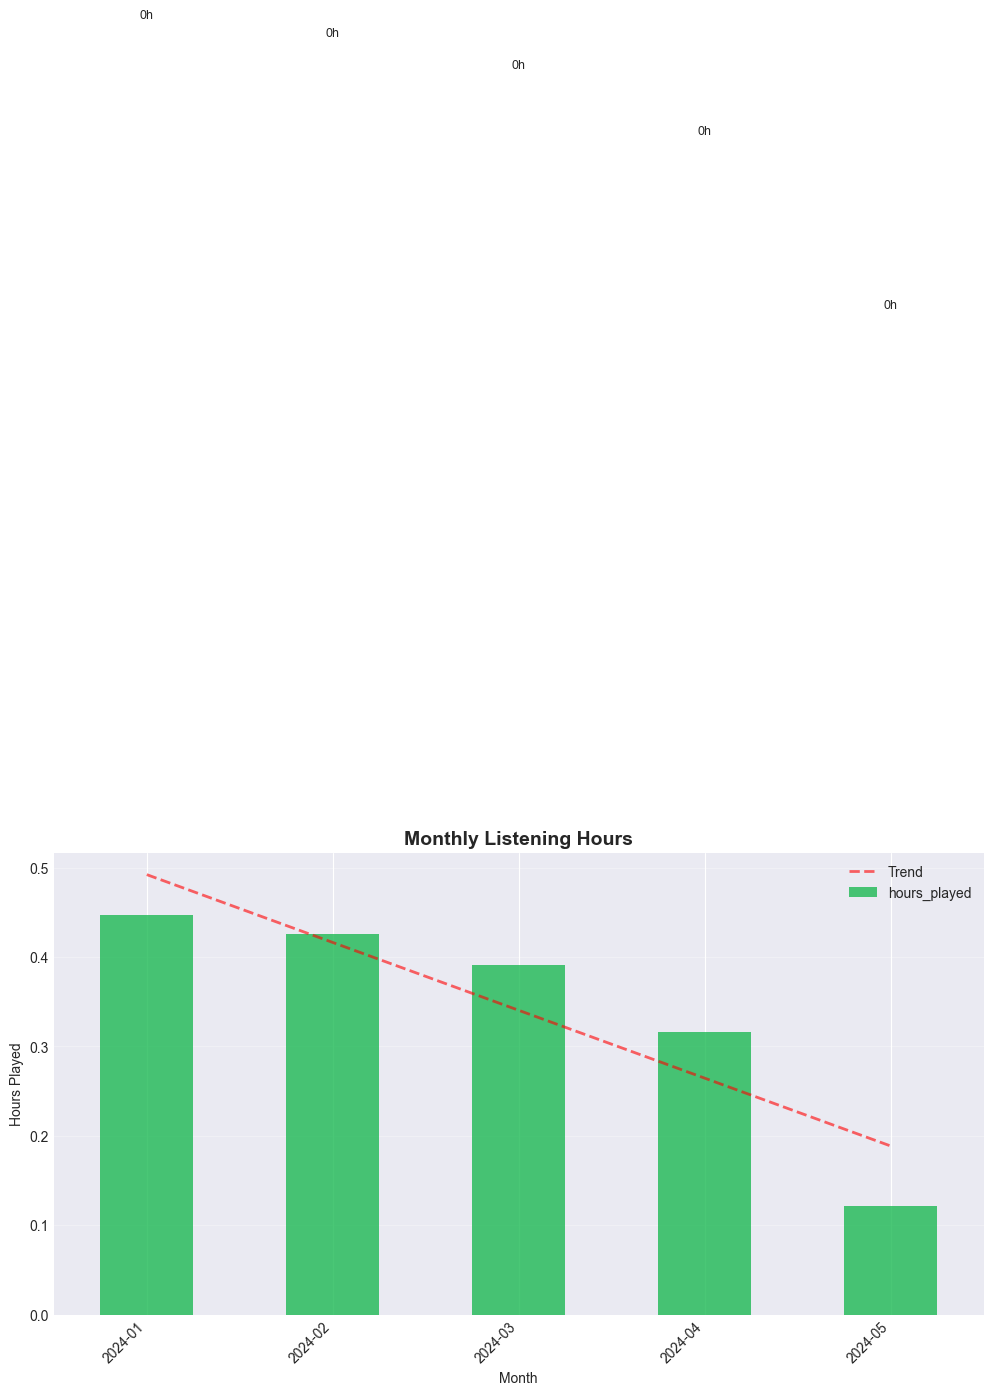

In [8]:
plot_monthly_hours(df)

**What this shows:**
- Total hours listened each month
- Trend line showing if usage is increasing/decreasing
- Identifies high and low usage months

### Cost Per Hour Over Time

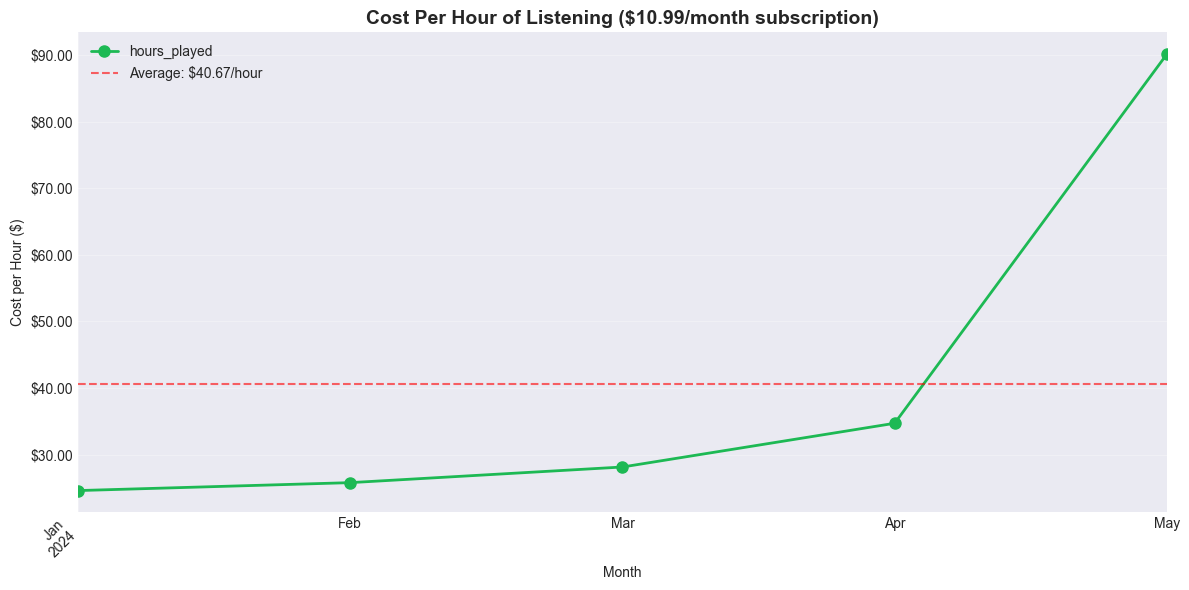

In [9]:
plot_cost_per_hour(df, SUBSCRIPTION_COST)

**What this shows:**
- How much you're paying per hour each month
- Lower = better value (more listening for same price)
- Helps identify months where subscription wasn't well utilized

### Hourly Listening Distribution

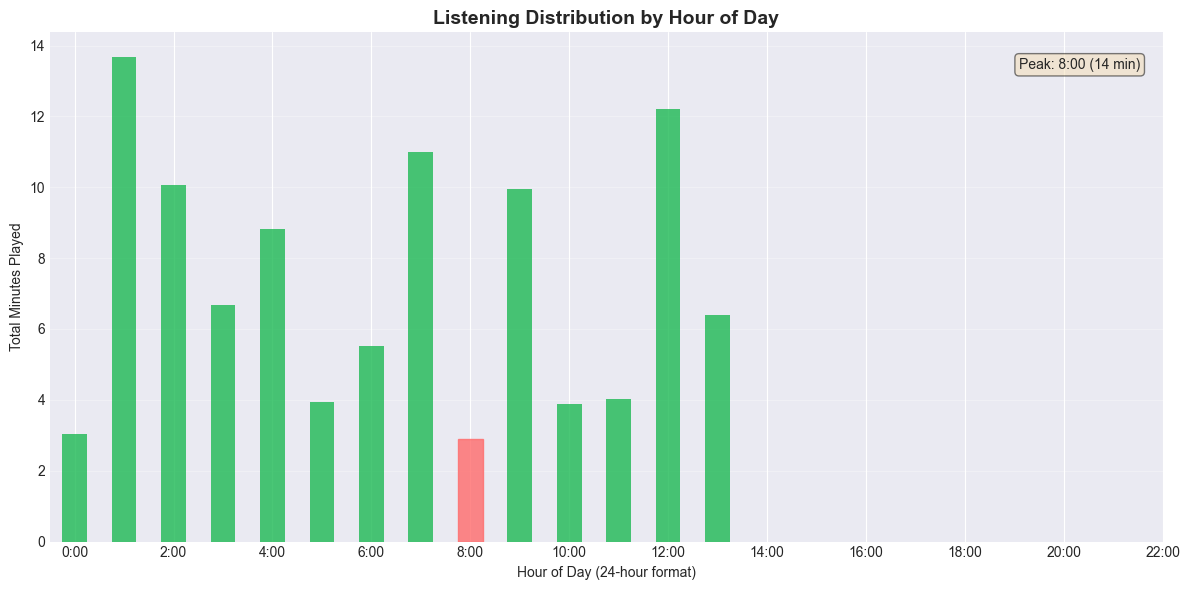

In [10]:
plot_hourly_distribution(df)

**What this shows:**
- When during the day you listen most
- Peak listening hours highlighted in red
- Useful for understanding your daily routine

### Weekday vs Weekend Comparison

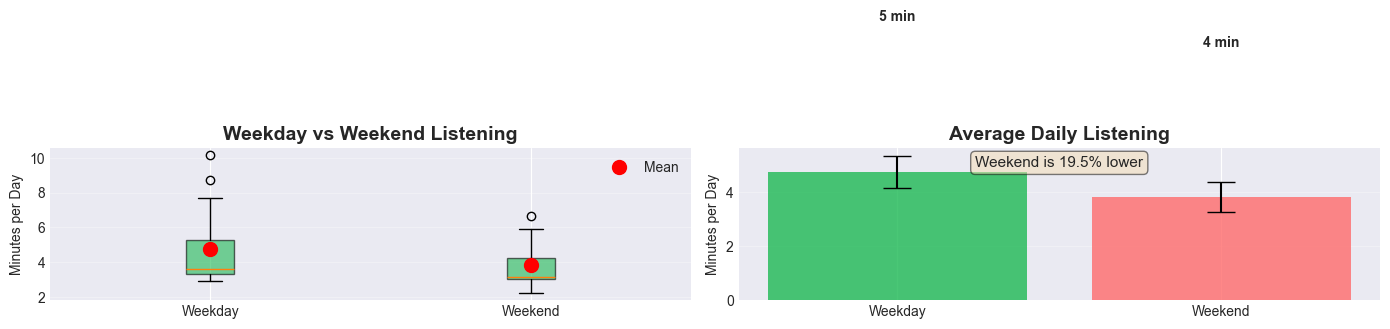

In [11]:
plot_weekday_weekend_comparison(df)

**What this shows:**
- Distribution of daily listening for weekdays vs weekends
- Statistical comparison with error bars
- Percentage difference between the two

## Step 6: Deep Dive - Top Artists and Tracks

In [12]:
# Top 10 most listened artists
top_artists = df.groupby('artistName')['hours_played'].sum().sort_values(ascending=False).head(10)

print("Top 10 Artists by Listening Time:")
for i, (artist, hours) in enumerate(top_artists.items(), 1):
    print(f"{i:2d}. {artist:40s} - {hours:6.1f} hours")

Top 10 Artists by Listening Time:
 1. Taylor Swift                             -    0.2 hours
 2. Arctic Monkeys                           -    0.1 hours
 3. Frank Ocean                              -    0.1 hours
 4. SZA                                      -    0.1 hours
 5. Hozier                                   -    0.1 hours
 6. Bad Bunny                                -    0.1 hours
 7. Lana Del Rey                             -    0.1 hours
 8. Beyoncé                                  -    0.1 hours
 9. Doja Cat                                 -    0.1 hours
10. Billie Eilish                            -    0.1 hours


In [13]:
# Top 10 most played tracks
top_tracks = df.groupby(['artistName', 'trackName'])['hours_played'].sum().sort_values(ascending=False).head(10)

print("Top 10 Tracks by Listening Time:")
for i, ((artist, track), hours) in enumerate(top_tracks.items(), 1):
    print(f"{i:2d}. {track:40s} by {artist:30s} - {hours:5.1f} hours")

Top 10 Tracks by Listening Time:
 1. Do I Wanna Know?                         by Arctic Monkeys                 -   0.1 hours
 2. 505                                      by Arctic Monkeys                 -   0.1 hours
 3. Too Sweet                                by Hozier                         -   0.1 hours
 4. Monaco                                   by Bad Bunny                      -   0.1 hours
 5. Young and Beautiful                      by Lana Del Rey                   -   0.1 hours
 6. TEXAS HOLD 'EM                           by Beyoncé                        -   0.1 hours
 7. Paint The Town Red                       by Doja Cat                       -   0.1 hours
 8. What Was I Made For?                     by Billie Eilish                  -   0.1 hours
 9. Lover                                    by Taylor Swift                   -   0.1 hours
10. vampire                                  by Olivia Rodrigo                 -   0.1 hours


## Summary and Insights

### Key Takeaways

Based on this analysis, here's what we learned:

1. **Usage Pattern:** [Your average monthly listening hours]
2. **Value:** [Your average cost per hour]
3. **Consistency:** [95% CI interpretation]
4. **Behavior:** [Weekend vs weekday pattern]
5. **Timing:** [Peak listening hours]

### Statistical Rigor

This analysis used:
- **T-distribution confidence intervals** (appropriate for small sample sizes)
- **Pearson correlation** (measures linear relationships)
- **Independent t-tests** (compares group means)
- **Cohen's d effect sizes** (measures practical significance)

### Potential Questions for Interviews

**Q: Why did you choose these specific statistics?**
- Cost per hour is directly interpretable and comparable
- Confidence intervals account for variability, not just point estimates
- Effect sizes show practical significance, not just statistical significance

**Q: What assumptions does this analysis make?**
- Monthly listening hours are approximately normally distributed (validated with CI calculation)
- Short plays (<30s) are not meaningful listening (validated by Spotify research)
- Listening behavior is reasonably stable over time

**Q: How would you extend this?**
- Add seasonal analysis (winter vs summer)
- Genre/mood analysis if that data becomes available
- Predictive model for future usage (though current approach is more interpretable)
- A/B test comparison if subscription features change

## Next Steps

Possible extensions:
1. Export this analysis as a PDF report
2. Set up monthly automated updates
3. Compare across different time periods (yearly trends)
4. Build a simple dashboard with streamlit
5. Compare your listening to friends (if they share data)